Prediciendo la diabetes

In [272]:
import json
import pandas as pd

url = "https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv"

total_data = pd.read_csv(url)
total_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Step 2: Exploración y Limpieza de Datos

In [273]:
# Obtener las dimensiones
total_data.shape

(768, 9)

In [274]:
# Obtener información de las columnas con valores nulos
total_data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

El dataset está completo, sin huecos que rellenar.

Step 3: Análisis de variables univariantes

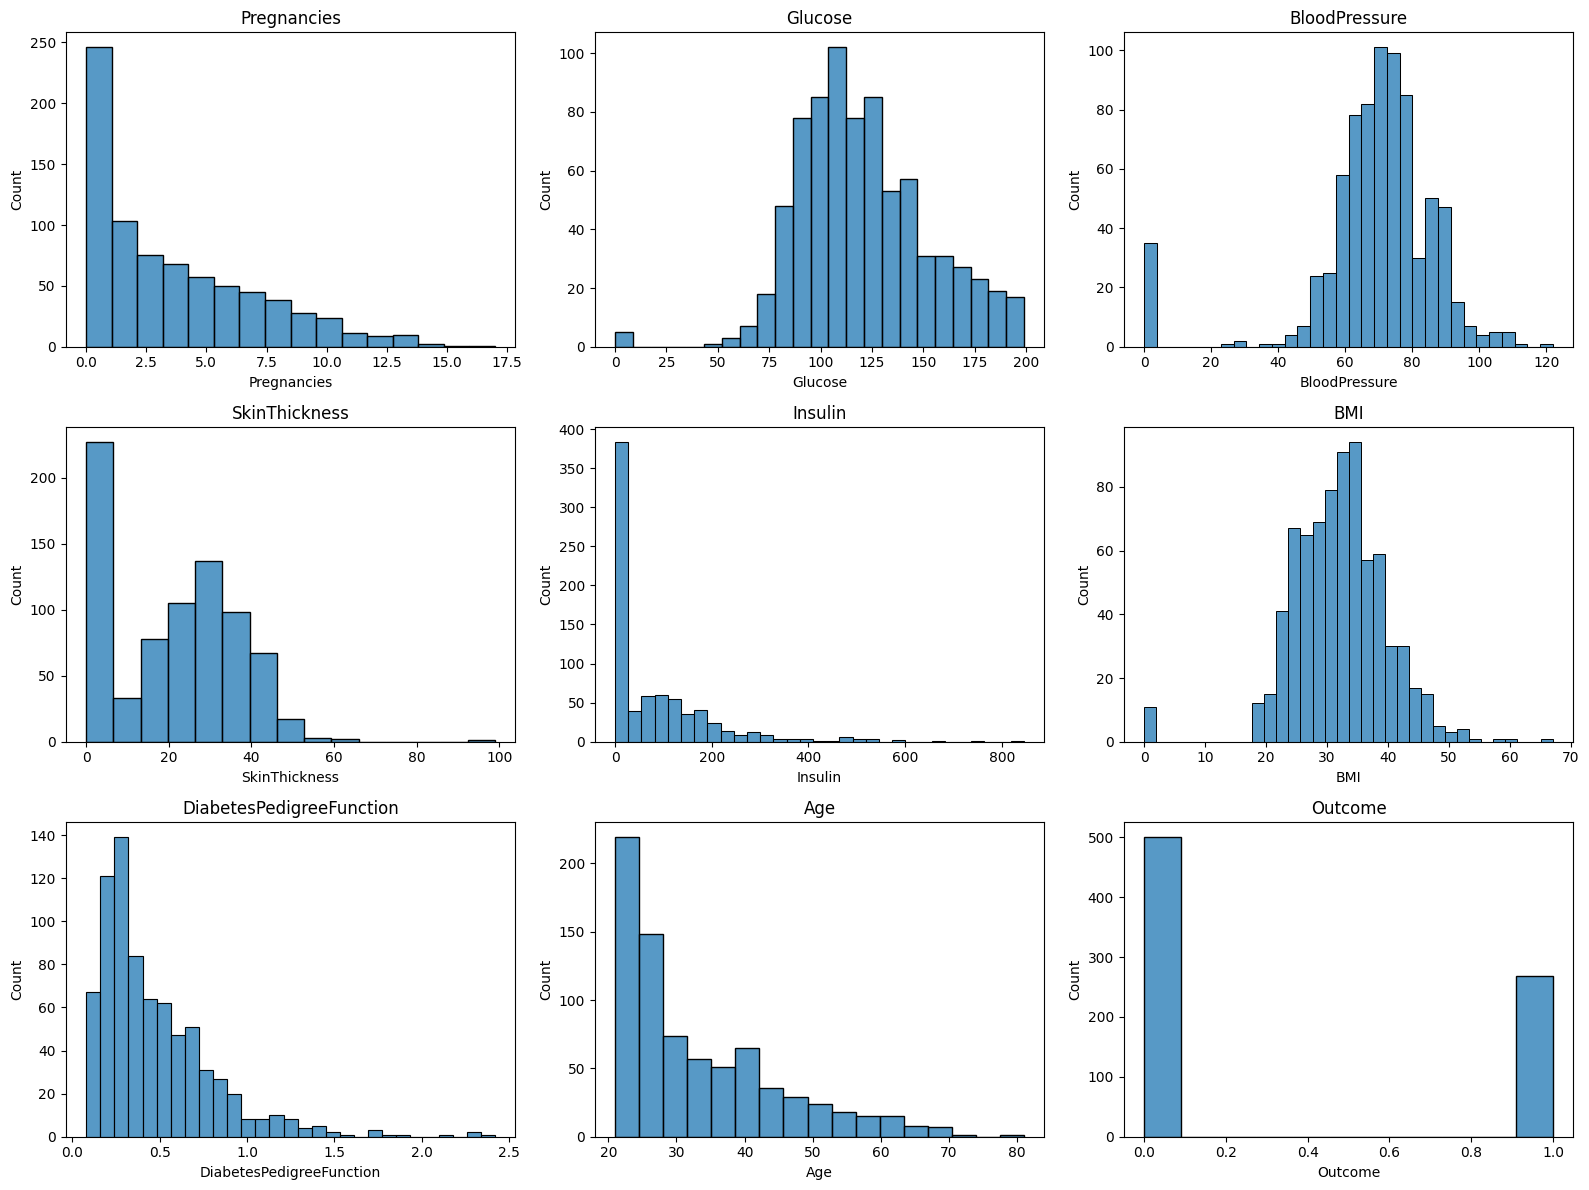

In [275]:
import seaborn as sns
import matplotlib.pyplot as plt

variables = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
             "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]

fig, axis = plt.subplots(3, 3, figsize=(16, 12))

for i, var in enumerate(variables):
    fila = i // 3
    col = i % 3
    sns.histplot(ax=axis[fila, col], data=total_data, x=var)
    axis[fila, col].set_title(var)

plt.tight_layout()
plt.show()


Existen valores nulos en variables como 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin' y 'BMI' por lo que supone existencia de datos faltantes.
>Por su naturaleza de las variables:
Númericas continuas: 'BMI', 'Glucose', 'BloodPressure'
Numéricas discretas: 'Pregnancies'
Categóricas binarias: 'Outcome' (YES/NO)
En este caso, la variable objetivo es 'Outcome'

Step 4: Análisis de Variable Multivariante

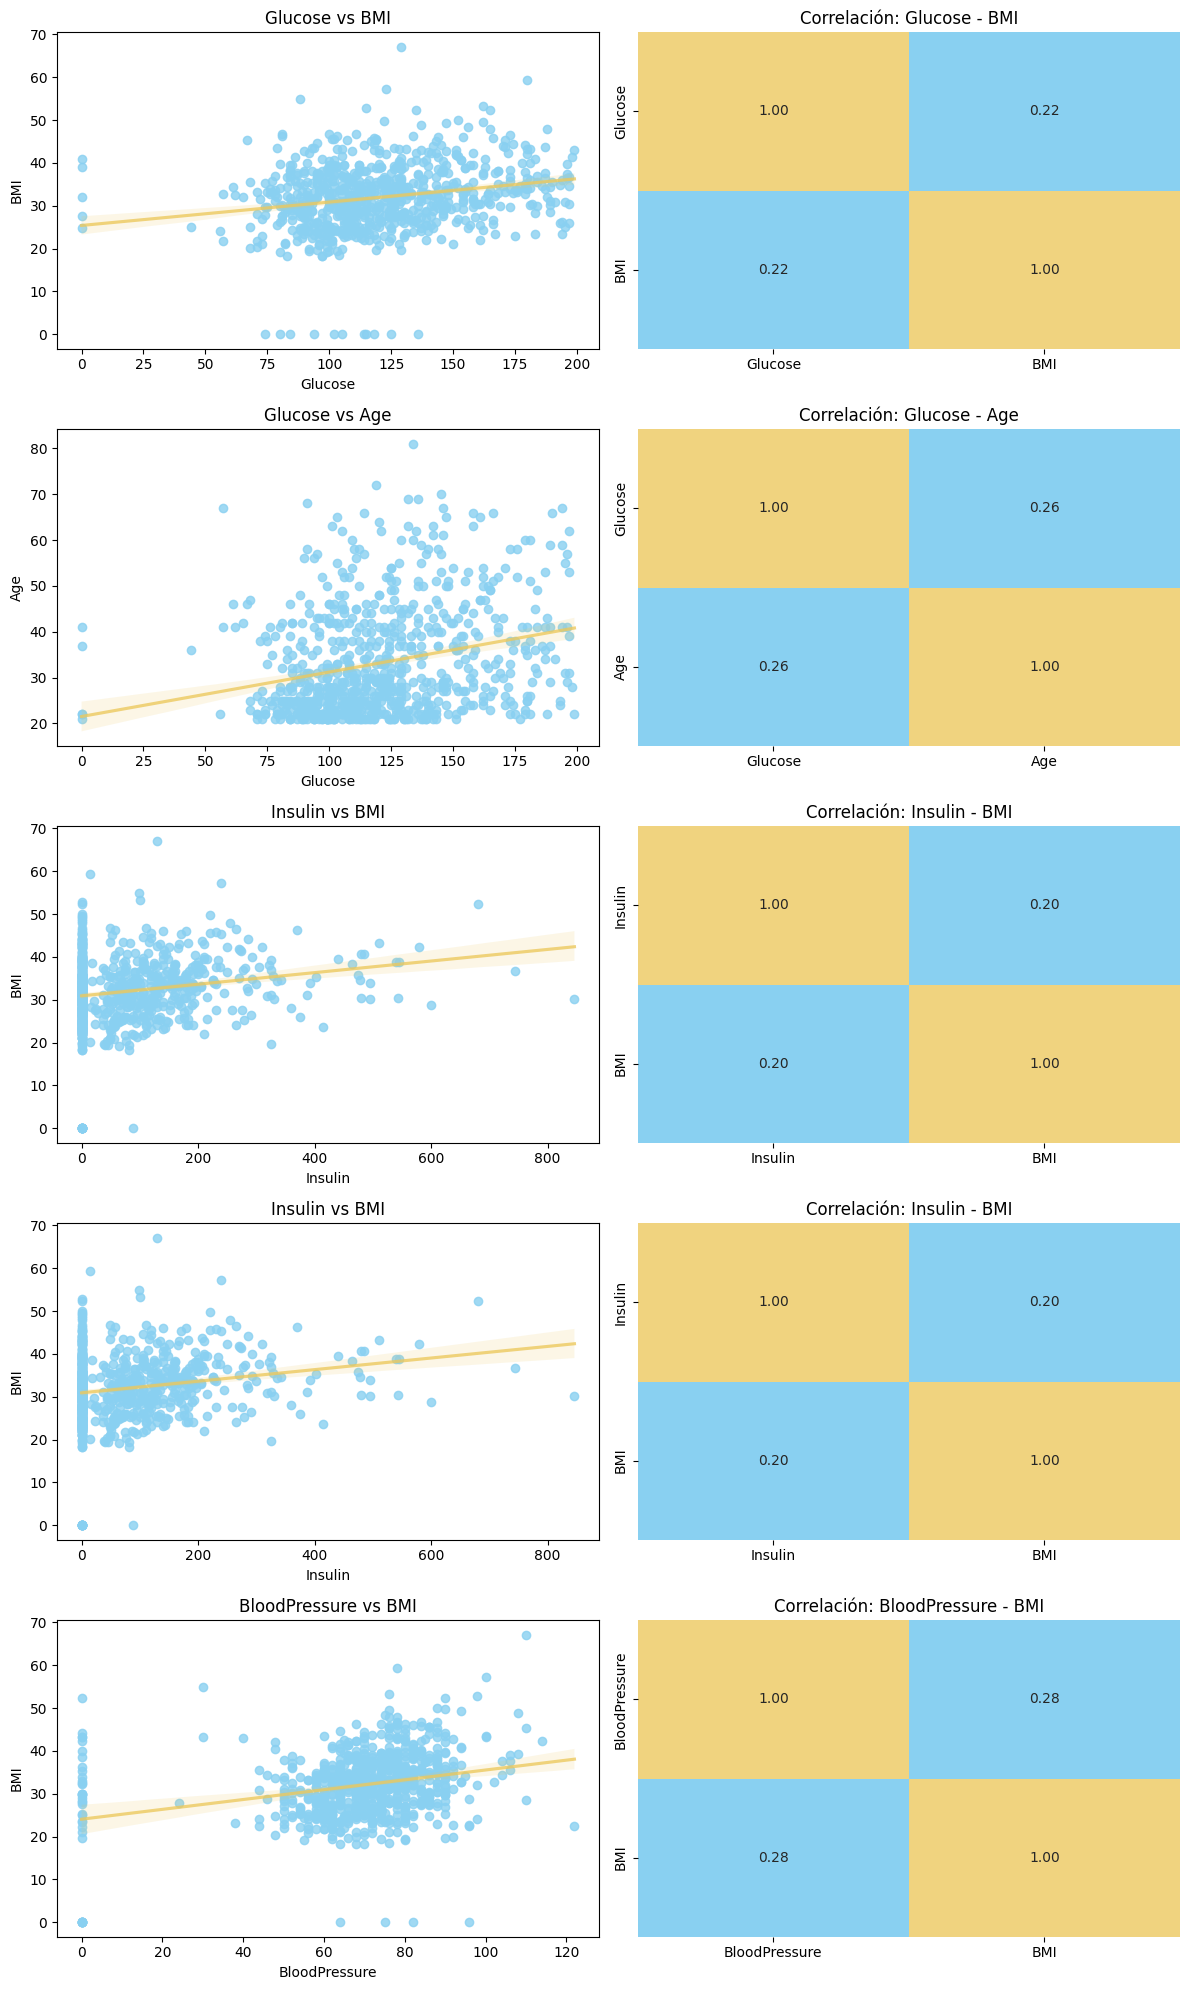

In [276]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

pairs = [
    ("Glucose", "BMI"),
    ("Glucose", "Age"),
    ("Insulin", "BMI"),
    ("Insulin", "BMI"),
    ("BloodPressure", "BMI")
]

# Crear paleta celeste → blanco → ámbar
cmap_custom = LinearSegmentedColormap.from_list(
    "celeste_ambar",
    ["#89D0F1", "white", "#ECC85CC8"]
)

fig, axes = plt.subplots(len(pairs), 2, figsize=(12, 4*len(pairs)))

for i, (x, y) in enumerate(pairs):

    # Regplot con colores personalizados
    sns.regplot(
        ax=axes[i, 0],
        data=total_data,
        x=x,
        y=y,
        scatter_kws={"color": "#89D0F1"},
        line_kws={"color": "#ECC85CC8"}
    )
    axes[i, 0].set_title(f"{x} vs {y}")

    # Heatmap con paleta personalizada
    corr = total_data[[x, y]].corr()
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap=cmap_custom,
        ax=axes[i, 1],
        cbar=False
    )
    axes[i, 1].set_title(f"Correlación: {x} - {y}")

plt.tight_layout()
plt.show()


INTERPRETACIÓN:
A mayor glucosa tiende a haber un IMC algo mayor, pero la relación más estrecha existe entre la Glucosa y la edad donde aumenta con tendencia ascendete conforme va teniendo más edad.

In [277]:
total_data["BMI_bin"] = pd.cut(
    total_data["BMI"],
    bins=[0, 18.5, 25, 30, 35, 40, 60],
    labels=["Bajo", "Normal", "Sobrepeso", "Obesidad I", "Obesidad II", "Obesidad III"]
)
total_data["Glucose_bin"] = pd.cut(
    total_data["Glucose"],
    bins=[0, 80, 100, 125, 150, 200, 300],
    labels=["<80", "80-100", "100-125", "125-150", "150-200", ">200"]
)

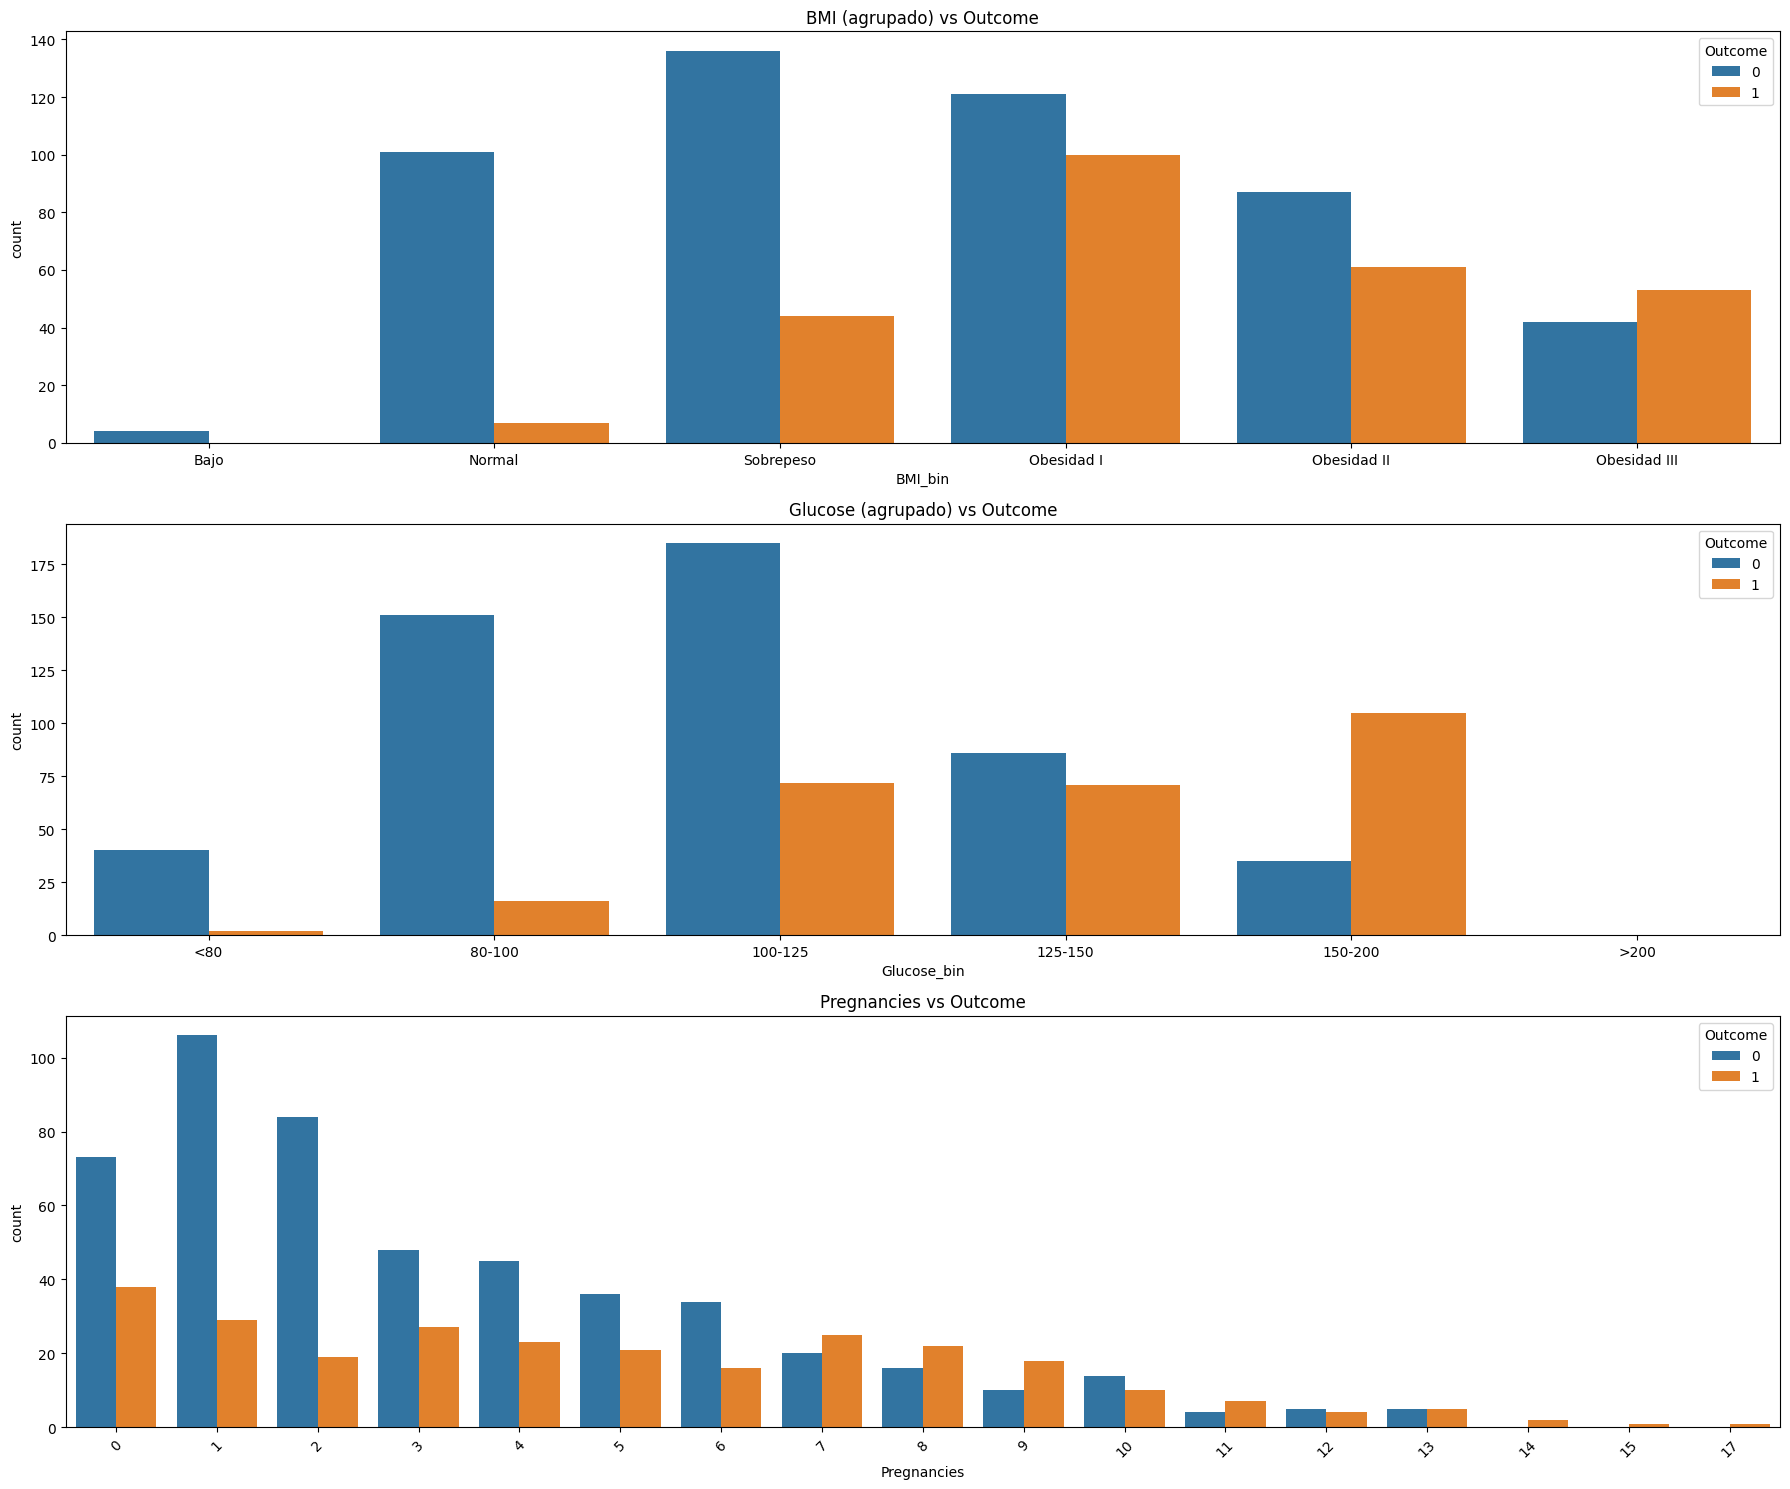

In [278]:
fig, axes = plt.subplots(3, 1, figsize=(18, 15))

# Gráfico 1: BMI agrupado
sns.countplot(
    ax=axes[0],
    data=total_data,
    x="BMI_bin",
    hue="Outcome"
)
axes[0].tick_params(axis='x', rotation=0)
axes[0].set_title("BMI (agrupado) vs Outcome")

# Gráfico 2: Glucose agrupado
sns.countplot(
    ax=axes[1],
    data=total_data,
    x="Glucose_bin",
    hue="Outcome"
)
axes[1].tick_params(axis='x', rotation=0)
axes[1].set_title("Glucose (agrupado) vs Outcome")

# Gráfico 3: Pregnancies (sin cambios)
sns.countplot(
    ax=axes[2],
    data=total_data,
    x="Pregnancies",
    hue="Outcome"
)
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_title("Pregnancies vs Outcome")

plt.tight_layout()
plt.show()


En el Primer Gráfico de Barras - IMC: El exceso de peso se asocia con mayor riesgo metabólico de resultar con Diabetes
En el Segundo Gráfico de Barras - Glucose: Niveles altos de glucosa están estrechamente ligados al diagnóstico de diabetes, lo cual es coherente con los criterios clínicos habituales.
En el Tercer Gráfico de Barras - Pregnacies: Algunos estudios se observa que más embarazos pueden asociarse a mayor riesgo de diabetes tipo 2, en parte por la relación con diabetes gestacional previa.

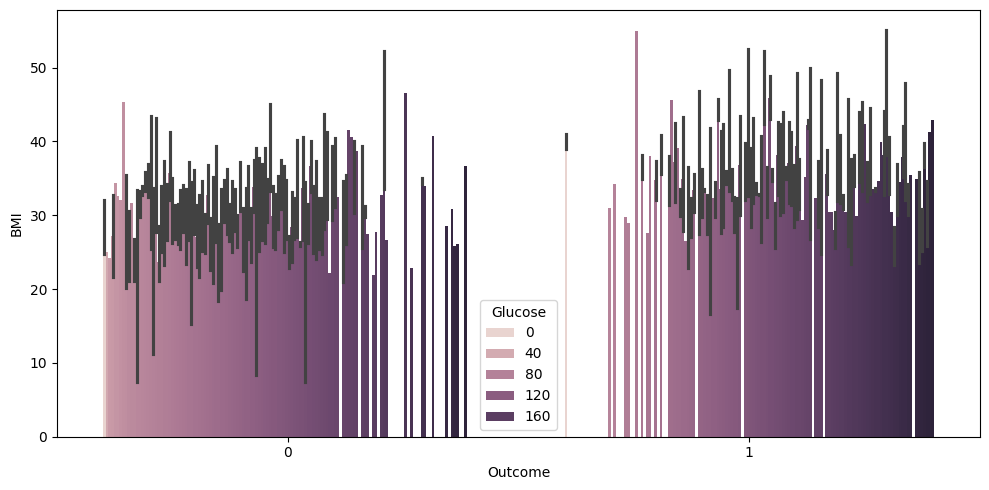

In [279]:
fig, axis = plt.subplots(figsize=(10, 5))

sns.barplot(ax=axis, data=total_data, x="Outcome", y="BMI", hue="Glucose")

plt.tight_layout()
plt.show()

Conclusión:
Las personas sin diabetes tienden a tener BMI moderado y glucosa baja. Asimismo, las personas con diabetes tienden a tener tanto más peso como más glucosa. 

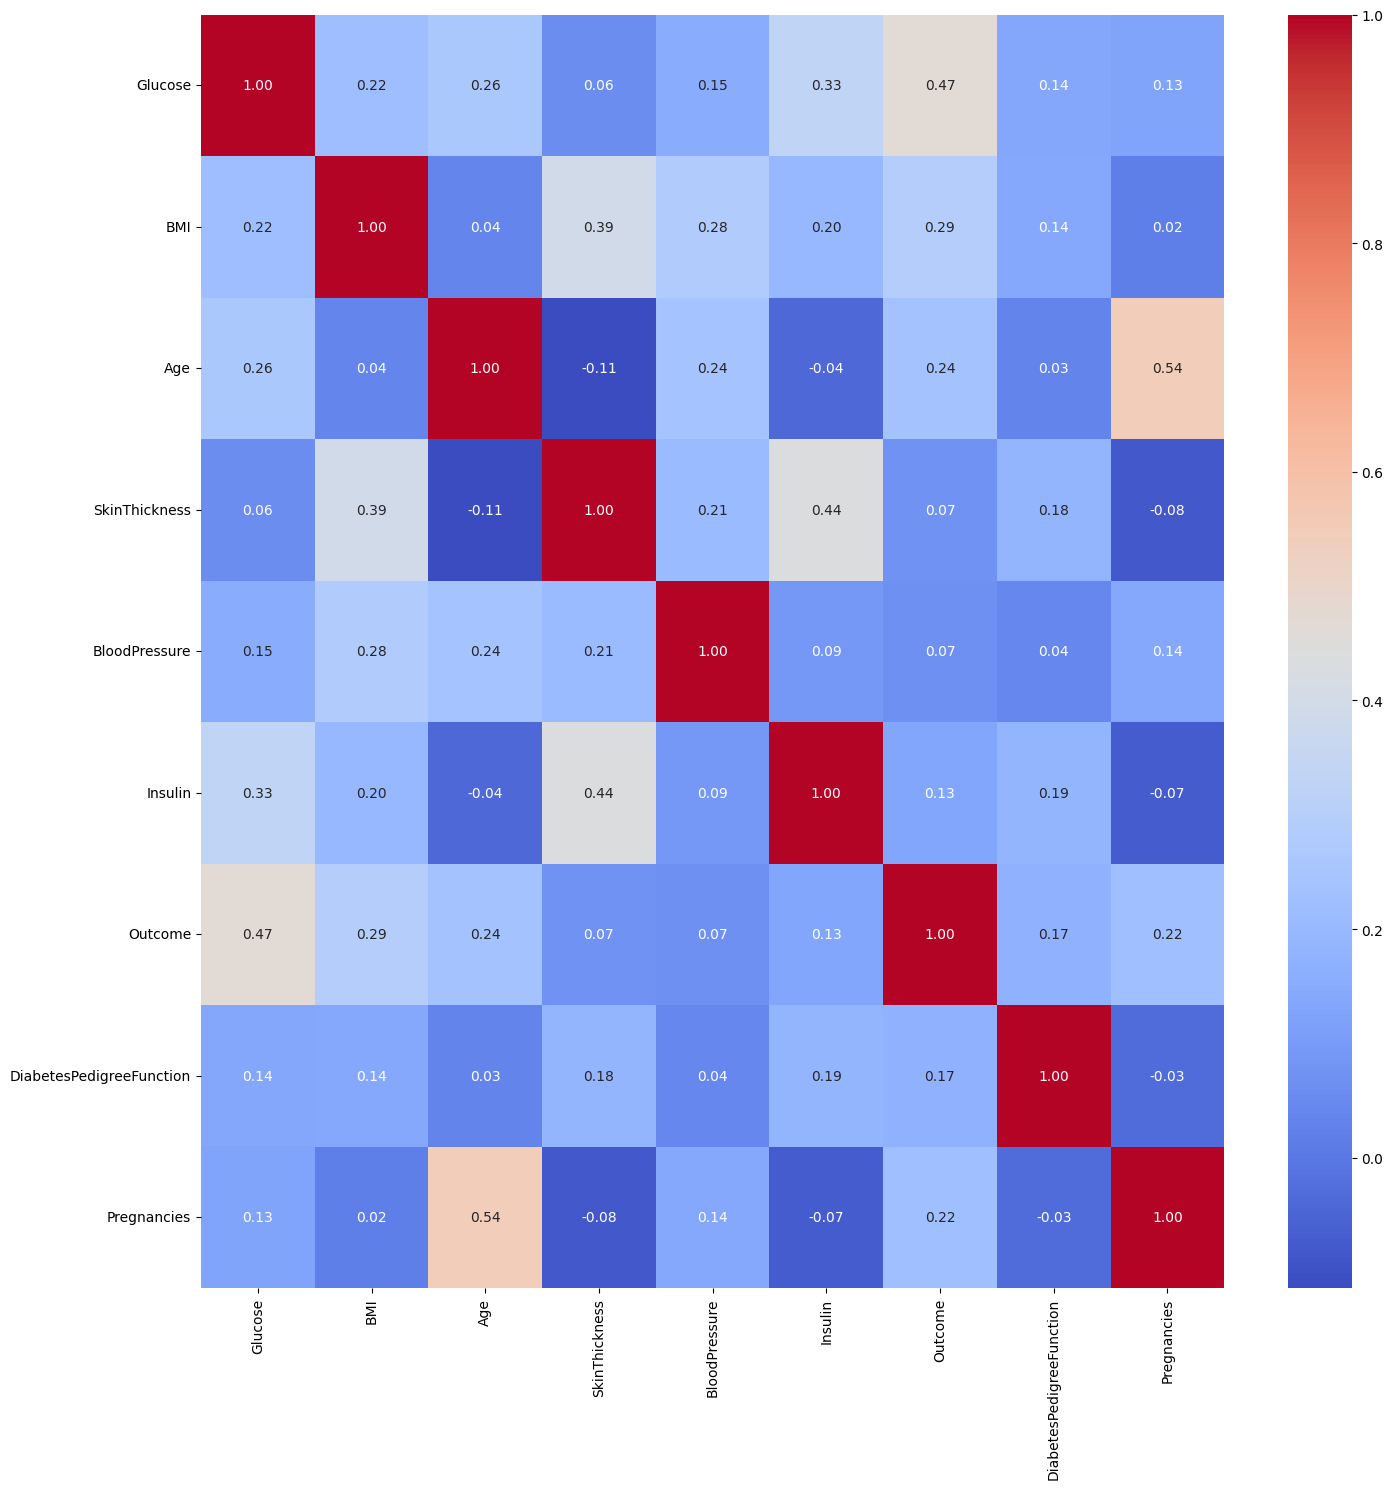

In [280]:
df_corr = total_data.copy()

# Dibujar el plot
plt.figure(figsize=(15, 15))
sns.heatmap(
    df_corr[["Glucose", "BMI", "Age", "SkinThickness", "BloodPressure",
             "Insulin", "Outcome", "DiabetesPedigreeFunction", "Pregnancies"]].corr(),
    annot=True, fmt=".2f", cmap="coolwarm"
)
plt.tight_layout()
plt.show()

Las variables que más se relacionan con el Outcome, con más riesgo de Diabetes son:

Glucose (la más fuerte con diferencia).

BMI (relación moderada).

Age y Pregnancies (relación moderada-baja).

El resto aporta información, pero con correlaciones bajas.

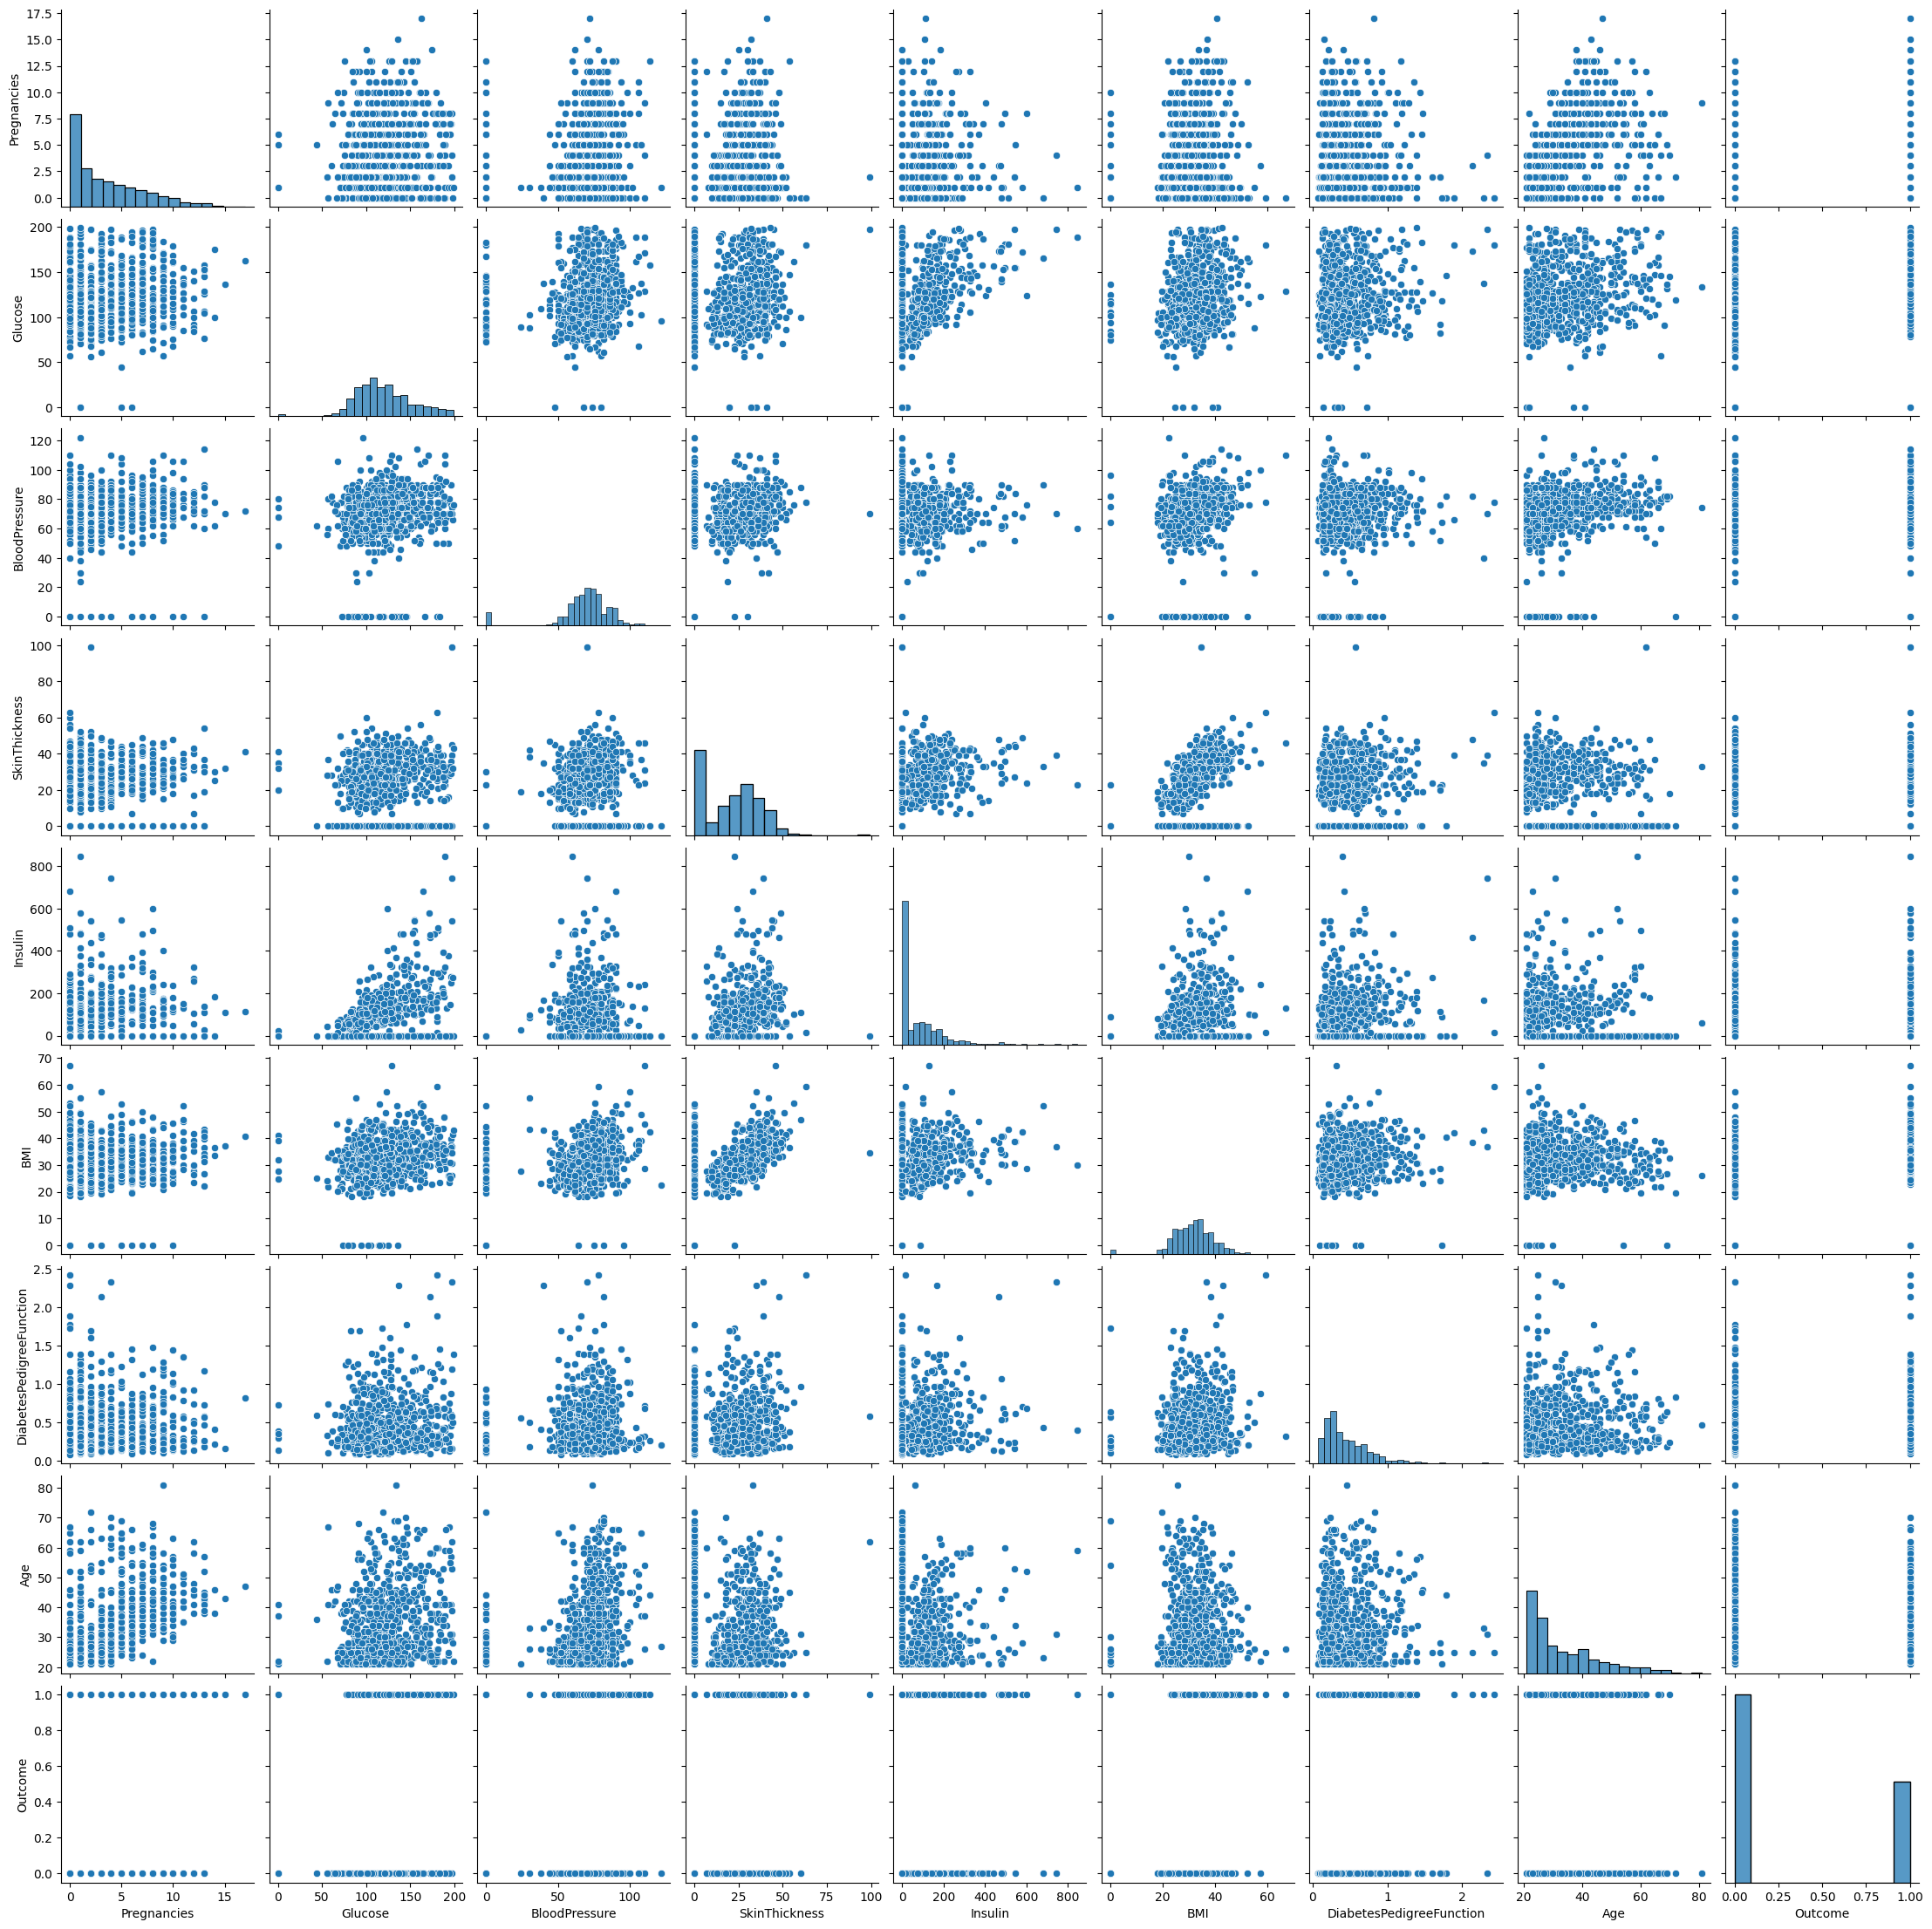

In [281]:
##ANÁLISIS DE TODA LA DATA EN UNA SOLA##
sns.pairplot(data = total_data)

Step 5: Ingeniería de Datos

In [282]:
total_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [283]:
import numpy as np

cols = ['Glucose', 'BloodPressure', 'Insulin', 'BMI', 'SkinThickness']

for col in cols:
    total_data[col] = total_data[col].replace(0, np.nan)


In [284]:
total_data = total_data.dropna(subset=cols)

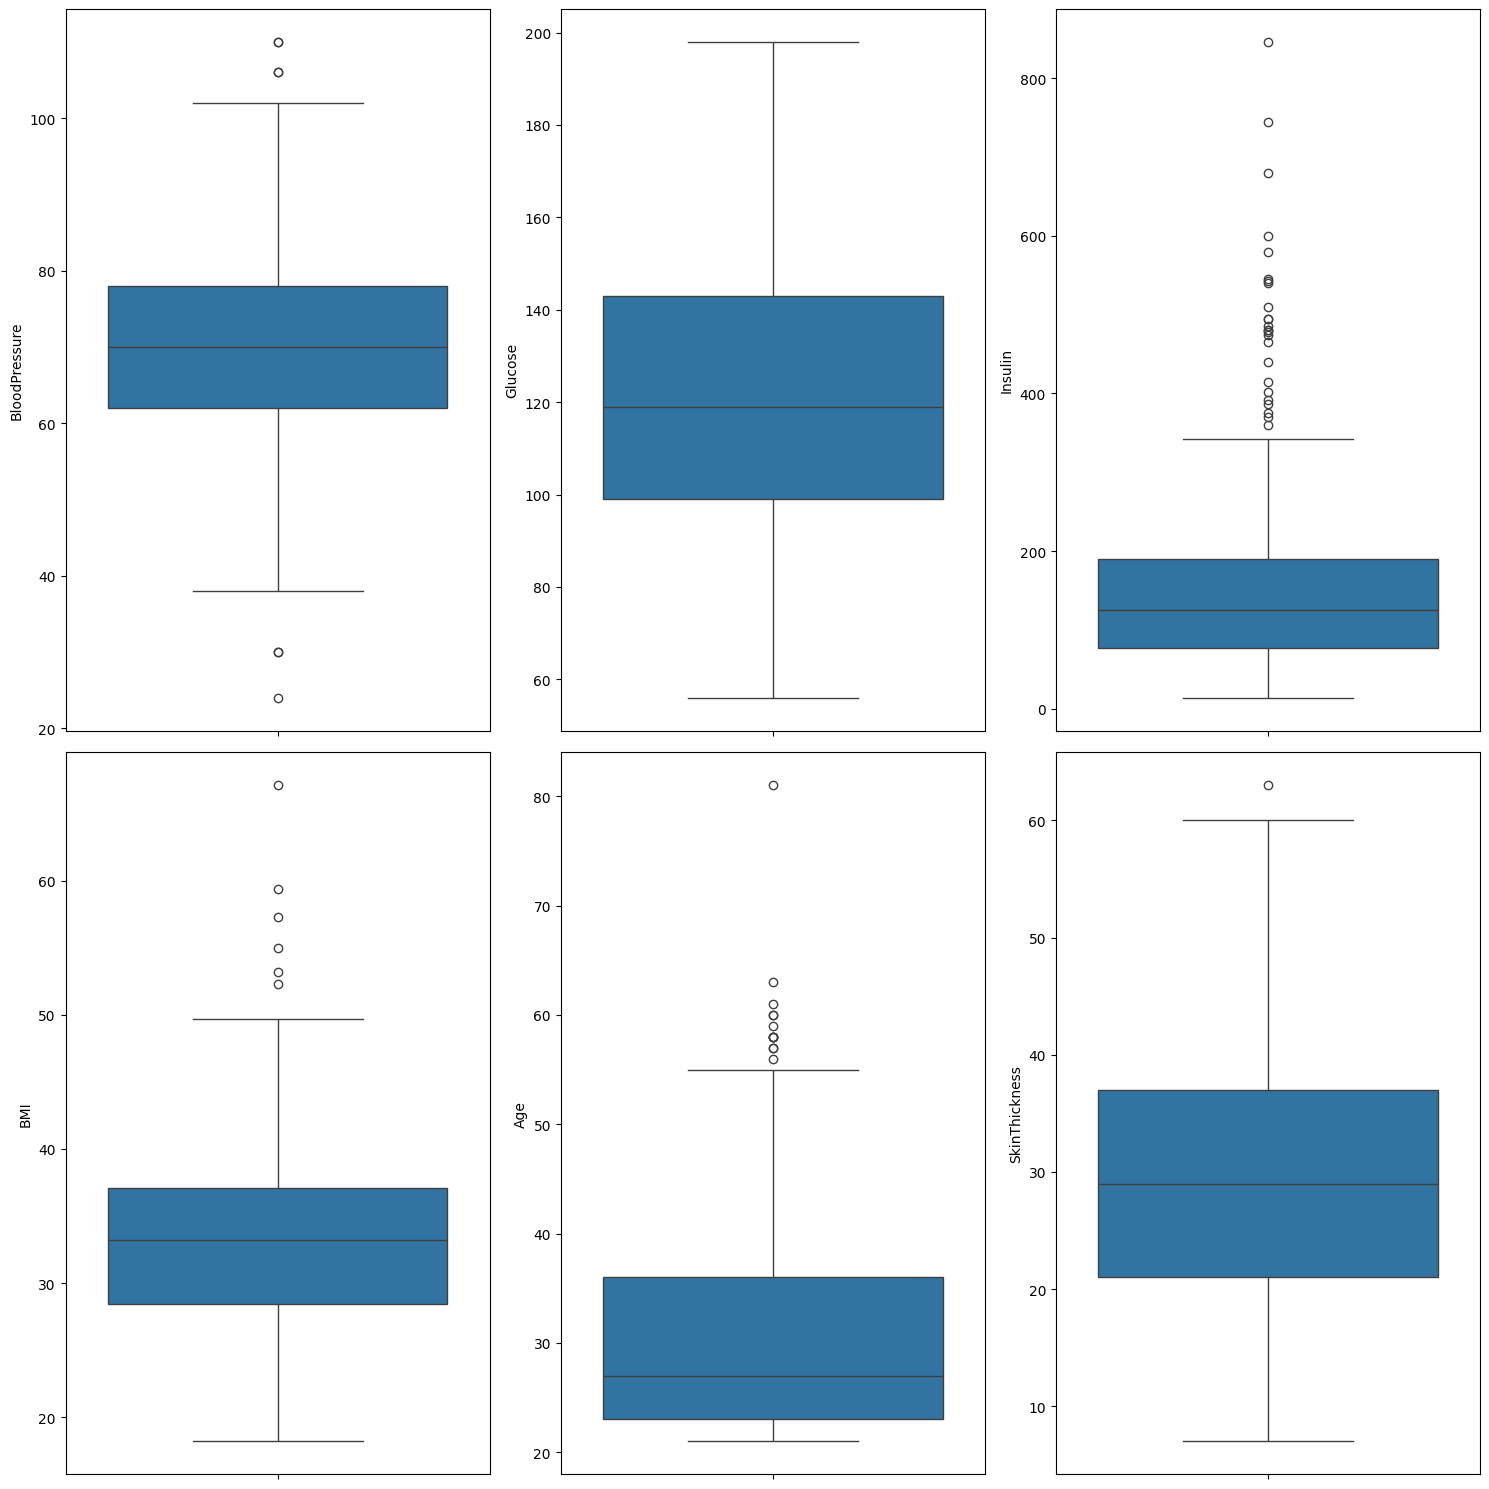

In [285]:
fig, axes = plt.subplots(2, 3, figsize = (15, 15))

sns.boxplot(ax = axes[0, 0], data = total_data, y = "BloodPressure")
sns.boxplot(ax = axes[0, 1], data = total_data, y = "Glucose")
sns.boxplot(ax = axes[0, 2], data = total_data, y = "Insulin")
sns.boxplot(ax = axes[1, 0], data = total_data, y = "BMI")
sns.boxplot(ax = axes[1, 1], data = total_data, y = "Age")
sns.boxplot(ax = axes[1, 2], data = total_data, y = "SkinThickness")

plt.tight_layout()

plt.show()

Variables limpias: 'BMI' y 'Age', de las cuales se pueden trabajar sin necesidad e eliminar outliers

Variables con outliers moderados: variable 'Pregnancies'.

Variables con problemas de calidad (valores 0): 'Glucose', 'Insulin', 'SkinThickness'.

Variables con dispersión extrema: 'Insulin'.

In [286]:
# Stats for 'Pregnancies'
pregnancies_stats = total_data["Pregnancies"].describe()
pregnancies_stats

count    392.000000
mean       3.301020
std        3.211424
min        0.000000
25%        1.000000
50%        2.000000
75%        5.000000
max       17.000000
Name: Pregnancies, dtype: float64

In [287]:
##Para la limpieza de outliers de BMI##
import numpy as np
total_data["log_BMI"] = np.log(total_data["BMI"])

In [288]:
# IQR para 'Pregnancies'

pregnancies_iqr = pregnancies_stats["75%"] - pregnancies_stats["25%"]
upper_limit = pregnancies_stats["75%"] + 1.5 * pregnancies_iqr
lower_limit = pregnancies_stats["25%"] - 1.5 * pregnancies_iqr

print(f"Los límites superior e inferior para la búsqueda de outliers son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(pregnancies_iqr, 2)}")

Los límites superior e inferior para la búsqueda de outliers son 11.0 y -5.0, con un rango intercuartílico de 4.0


Hemos visto que para la variable 'Pregnancies', 'Glucose', 'Insulin' y 'SkinThickness' se requiere una limpieza de outliers

In [289]:
##Para la limpieza de outliers de la cola derecha, valores muy altos##
import numpy as np
max_allowed = 10  # por ejemplo
total_data['Pregnancies_capped'] = total_data['Pregnancies'].apply(lambda x: min(x, max_allowed))

Con este tipo de limpieza intento hacer lo siguiente: Sustituye todos los valores mayores que 10 por 10, ya sea que sea un valor >= que 10.

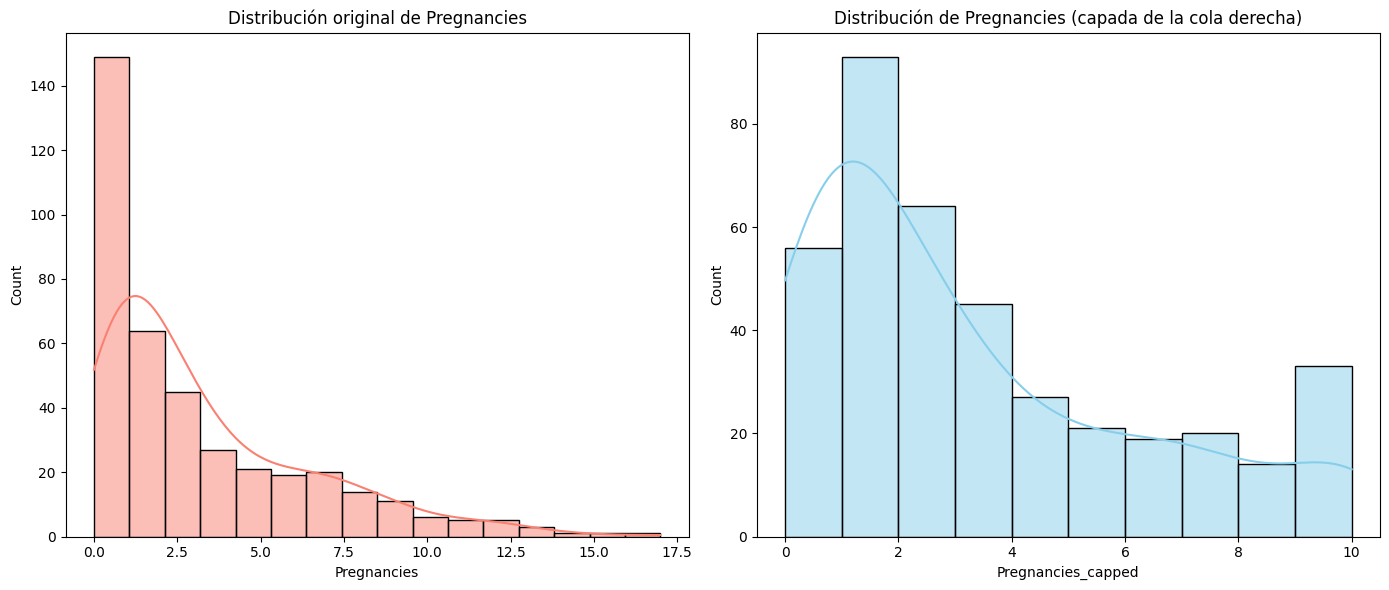

In [290]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Crear la variable capada (sin log)
max_allowed = 10
total_data["Pregnancies_capped"] = total_data["Pregnancies"].apply(lambda x: min(x, max_allowed))

# Graficar comparaciones
plt.figure(figsize=(14, 6))

# Distribución original
plt.subplot(1, 2, 1)
sns.histplot(total_data["Pregnancies"], kde=True, color="salmon")
plt.title("Distribución original de Pregnancies")
plt.xlabel("Pregnancies")

# Distribución capada
plt.subplot(1, 2, 2)
sns.histplot(total_data["Pregnancies_capped"], kde=True, color="skyblue")
plt.title("Distribución de Pregnancies (capada de la cola derecha)")
plt.xlabel("Pregnancies_capped")

plt.tight_layout()
plt.show()


In [291]:
from numpy._core.defchararray import upper
# TENEMOS QUE GUARDARNOS TODOS LOS DATASETS, ES DECIR:

total_data_CON_outliers = total_data.copy()
total_data_SIN_outliers = total_data.copy() # Lo vamos a modificar. Para cada variable con outliers, reemplazamos sus valores outliers

outliers_cols = ["Age", "BMI", "Glucose", "Insulin","BloodPressure", "Outcome"]

def replace_outliers(column, df):
  col_stats = total_data[column].describe()
  col_iqr = col_stats["75%"] - col_stats["25%"]
  upper_limit = round(float(col_stats["75%"] + 1.5 * col_iqr), 2)
  lower_limit = round(float(col_stats["25%"] - 1.5 * col_iqr), 2)

  if lower_limit < 0: lower_limit = min(df[column])
  # Vamos a quitar los outliers superiores
  df[column] = df[column].apply(lambda x: x if (x <= upper_limit) else upper_limit)
  # Vamos a quitar los outliers inferiores
  df[column] = df[column].apply(lambda x: x if (x >= lower_limit) else lower_limit)
  return df.copy(), [lower_limit, upper_limit]

outliers_dict = {}
for column in outliers_cols:
  total_data_SIN_outliers, limits = replace_outliers(column, total_data_SIN_outliers)
  outliers_dict.update({column: limits})

outliers_dict # Este JSON me lo tengo que GUARDAR

{'Age': [3.5, 55.5],
 'BMI': [15.35, 50.15],
 'Glucose': [33.0, 209.0],
 'Insulin': [14.0, 359.88],
 'BloodPressure': [38.0, 102.0],
 'Outcome': [0, 2.5]}

In [292]:
with open("./outliers_dict.json", "w") as f:
  json.dump(outliers_dict, f)

In [293]:
total_data_CON_outliers.isnull().sum().sort_values(ascending=False)

BMI_bin                     1
Glucose                     0
BloodPressure               0
SkinThickness               0
Pregnancies                 0
Insulin                     0
BMI                         0
Age                         0
DiabetesPedigreeFunction    0
Outcome                     0
Glucose_bin                 0
log_BMI                     0
Pregnancies_capped          0
dtype: int64

In [294]:
total_data_SIN_outliers.isnull().sum().sort_values(ascending=False)

BMI_bin                     1
Glucose                     0
BloodPressure               0
SkinThickness               0
Pregnancies                 0
Insulin                     0
BMI                         0
Age                         0
DiabetesPedigreeFunction    0
Outcome                     0
Glucose_bin                 0
log_BMI                     0
Pregnancies_capped          0
dtype: int64

In [295]:
total_data_CON_outliers = total_data.copy()

cols = ["BMI", "Glucose"]
for col in cols:
    total_data_CON_outliers[col] = total_data_CON_outliers[col].fillna(total_data_CON_outliers[col].median())

# Recalcular variables derivadas
total_data_CON_outliers["BMI_bin"] = pd.cut(
    total_data_CON_outliers["BMI"],
    bins=[0, 18.5, 25, 30, 100],
    labels=["Bajo", "Normal", "Sobrepeso", "Obesidad"]
)

In [296]:
total_data_CON_outliers.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
BMI_bin                     0
Glucose_bin                 0
log_BMI                     0
Pregnancies_capped          0
dtype: int64

In [297]:
total_data_CON_outliers["BMI"] = total_data["BMI"]
total_data_SIN_outliers["BMI"] = total_data_SIN_outliers["BMI"]

In [298]:
total_data_CON_outliers["Glucose"] = total_data["Glucose"]
total_data_SIN_outliers["Glucose"] = total_data_SIN_outliers["Glucose"]

In [299]:
total_data_CON_outliers["Probabilidad"] = (
    total_data_CON_outliers["Glucose"] + total_data_CON_outliers["BMI"]
)

total_data_SIN_outliers["Probabilidad"] = (
    total_data_SIN_outliers["Glucose"] + total_data_SIN_outliers["BMI"]
)


In [300]:
import sklearn
from sklearn.model_selection import train_test_split

# total_data_SIN_outliers
# total_data_CON_outliers

predictoras = ["Age", "BMI", "Glucose", "Insulin", "BloodPressure"]
target = ["Outcome"]

X_CON = total_data_CON_outliers.drop(target, axis = 1)[predictoras]
X_SIN = total_data_SIN_outliers.drop(target, axis = 1)[predictoras]
y = total_data_CON_outliers[target]

X_train_CON_outliers, X_test_CON_outliers, y_train, y_test = train_test_split(X_CON, y, test_size = 0.2, random_state = 10)
X_train_SIN_outliers, X_test_SIN_outliers = train_test_split(X_SIN, test_size = 0.2, random_state = 10)


In [301]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# X_train_CON_outliers
# X_train_SIN_outliers

# X_test_CON_outliers
# X_test_SIN_outliers

# TENGO QUE GUARDARME TRES SITUACIONES: 1) DATASET SIN TOCAR, 2) DATASET NORMALIZADO, 3) DATASET MIN-MAX

## NORMALIZACIÓN
### CON OUTLIERS
norm_CON_outliers = StandardScaler()
norm_CON_outliers.fit(X_train_CON_outliers)

X_train_CON_outliers_norm = norm_CON_outliers.transform(X_train_CON_outliers)
X_train_CON_outliers_norm = pd.DataFrame(X_train_CON_outliers_norm, index = X_train_CON_outliers.index, columns = predictoras)

X_test_CON_outliers_norm = norm_CON_outliers.transform(X_test_CON_outliers)
X_test_CON_outliers_norm = pd.DataFrame(X_test_CON_outliers_norm, index = X_test_CON_outliers.index, columns = predictoras)

### SIN OUTLIERS
norm_SIN_outliers = StandardScaler()
norm_SIN_outliers.fit(X_train_SIN_outliers)

X_train_SIN_outliers_norm = norm_SIN_outliers.transform(X_train_SIN_outliers)
X_train_SIN_outliers_norm = pd.DataFrame(X_train_SIN_outliers_norm, index = X_train_SIN_outliers.index, columns = predictoras)

X_test_SIN_outliers_norm = norm_SIN_outliers.transform(X_test_SIN_outliers)
X_test_SIN_outliers_norm = pd.DataFrame(X_test_SIN_outliers_norm, index = X_test_SIN_outliers.index, columns = predictoras)


## ESCALADO MIN-MAX (MINMAXIMIZACIÓN)
### CON OUTLIERS
scaler_CON_outliers = MinMaxScaler()
scaler_CON_outliers.fit(X_train_CON_outliers)

X_train_CON_outliers_scal = scaler_CON_outliers.transform(X_train_CON_outliers)
X_train_CON_outliers_scal = pd.DataFrame(X_train_CON_outliers_scal, index = X_train_CON_outliers.index, columns = predictoras)

X_test_CON_outliers_scal = scaler_CON_outliers.transform(X_test_CON_outliers)
X_test_CON_outliers_scal = pd.DataFrame(X_test_CON_outliers_scal, index = X_test_CON_outliers.index, columns = predictoras)

### SIN OUTLIERS
scaler_SIN_outliers = MinMaxScaler()
scaler_SIN_outliers.fit(X_train_SIN_outliers)

X_train_SIN_outliers_scal = scaler_SIN_outliers.transform(X_train_SIN_outliers)
X_train_SIN_outliers_scal = pd.DataFrame(X_train_SIN_outliers_scal, index = X_train_SIN_outliers.index, columns = predictoras)

X_test_SIN_outliers_scal = scaler_SIN_outliers.transform(X_test_SIN_outliers)
X_test_SIN_outliers_scal = pd.DataFrame(X_test_SIN_outliers_scal, index = X_test_SIN_outliers.index, columns = predictoras)

# X_train_CON_outliers
# X_train_CON_outliers_norm
# X_train_CON_outliers_scal
# X_train_SIN_outliers
# X_train_SIN_outliers_norm
# X_train_SIN_outliers_scal

# X_test_CON_outliers
# X_test_CON_outliers_norm
# X_test_CON_outliers_scal
# X_test_SIN_outliers
# X_test_SIN_outliers_norm
# X_test_SIN_outliers_scal

In [302]:
X_train_CON_outliers.to_excel("../data/processed/X_train_CON_outliers.xlsx")
X_train_CON_outliers.to_excel("../data/processed/X_train_CON_outliers_norm.xlsx")
X_train_CON_outliers_scal.to_excel("../data/processed/X_train_CON_outliers_scal.xlsx")

X_train_SIN_outliers.to_excel("../data/processed/X_train_SIN_outliers.xlsx")
X_train_SIN_outliers_norm.to_excel("../data/processed/X_train_SIN_outliers_norm.xlsx")
X_train_SIN_outliers_scal.to_excel("../data/processed/X_train_SIN_outliers_scal.xlsx")

y_train.to_excel("../data/processed/y_train.xlsx")

In [303]:
import pandas as pd

X_train_CON_outliers = pd.read_excel("../data/processed/X_train_CON_outliers.xlsx")
X_train_CON_outliers_norm = pd.read_excel("../data/processed/X_train_CON_outliers_norm.xlsx")
X_train_CON_outliers_scal = pd.read_excel("../data/processed/X_train_CON_outliers_scal.xlsx")

X_train_SIN_outliers = pd.read_excel("../data/processed/X_train_SIN_outliers.xlsx")
X_train_SIN_outliers_norm = pd.read_excel("../data/processed/X_train_SIN_outliers_norm.xlsx")
X_train_SIN_outliers_scal = pd.read_excel("../data/processed/X_train_SIN_outliers_scal.xlsx")

y_train = pd.read_excel("../data/processed/y_train.xlsx")

In [304]:
# Data processing
# ==================================================================================
import pandas as pd
import numpy as np

# Charts
# ==================================================================================
import matplotlib.pyplot as plt

# Preprocessing and modeling
# ==================================================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import ParameterGrid
# from sklearn.inspection import permutation_importance
from sklearn import tree


Step 1: Tomando decisión: Cuál es el mejor dataset

In [305]:
X_train_CON_outliers = pd.read_excel("../data/processed/X_train_CON_outliers.xlsx")
X_train_SIN_outliers = pd.read_excel("../data/processed/X_train_SIN_outliers.xlsx")
y_train = pd.read_excel("../data/processed/y_train.xlsx")

In [306]:
y_train = y_train.values.ravel()

In [307]:
y_test = y_test.values.ravel()

In [308]:
##Eliminar Unnamed: 0 en todos los dataframes antes de entrenar##
for name in dir():
    obj = eval(name)
    if hasattr(obj, "columns") and "Unnamed: 0" in obj.columns:
        obj.drop(columns=["Unnamed: 0"], inplace=True)


In [309]:
train_dicts = {
  "X_train_CON_outliers": X_train_CON_outliers,
  "X_train_SIN_outliers": X_train_SIN_outliers
}

# test_dicts (dict)
# =====================================================================================
test_dicts = {
  "X_test_CON_outliers": X_test_CON_outliers,
  "X_test_SIN_outliers": X_test_SIN_outliers
}

# -.-.--.-.-.-.-.-.-.-.--.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.--.-.-.-.-.-.-

# train_dfs (list)
# =====================================================================================
train_dfs = [
  X_train_CON_outliers,
  X_train_SIN_outliers
]

# test_dfs (list)
# =====================================================================================
test_dfs = [
  X_test_CON_outliers,
  X_test_SIN_outliers
]

# -.-.--.-.-.-.-.-.-.-.--.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.--.-.-.-.-.-.-

# Print .shape
# =====================================================================================
print("|X_train|")
print("=================================================================")
print(f"X_train_CON_outliers shape: {X_train_CON_outliers.shape} ")
print(f"X_train_SIN_outliers shape: {X_train_SIN_outliers.shape}\n ")

print("|X_test|")
print("=================================================================")
print(f"X_test_CON_outliers shape: {X_test_CON_outliers.shape} ")
print(f"X_test_SIN_outliers shape: {X_test_SIN_outliers.shape}\n ")

print("|Y_train|")
print("=================================================================")
print(f"y_train shape: {y_train.shape}\n ")

print("|Y_test|")
print("=================================================================")
print(f"y_test shape: {y_test.shape} ")

|X_train|
X_train_CON_outliers shape: (313, 5) 
X_train_SIN_outliers shape: (313, 5)
 
|X_test|
X_test_CON_outliers shape: (79, 5) 
X_test_SIN_outliers shape: (79, 5)
 
|Y_train|
y_train shape: (626,)
 
|Y_test|
y_test shape: (79,) 


In [310]:
import pandas as pd

# Convertir y_train en Series con índice consecutivo
y_train = pd.Series(y_train)


El dataframe que se considera entrenar en principio tiene 313 filas y el eje "Y" tiene 626 filas

In [311]:
print(train_dfs[0].shape, y_train_dfs[0].shape)
print(train_dfs[1].shape, y_train_dfs[1].shape)

(313, 5) (313,)
(313, 5) (313,)


In [312]:
from sklearn.tree import DecisionTreeClassifier

results = []

for df_index in range(len(train_dfs)):
    model = DecisionTreeClassifier(random_state=42)

    train_df = train_dfs[df_index]
    y_sub = y_train_dfs[df_index]

    model.fit(train_df, y_sub)

    y_test_pred = model.predict(test_dfs[df_index])

    results.append({
        "index": df_index,
        "train_df": list(train_dicts.keys())[df_index],
        "Accuracy_score": accuracy_score(y_test, y_test_pred)
    })

resultados = sorted(results, key=lambda x: x["Accuracy_score"], reverse=True)
resultados


/home/vscode/.local/lib/python3.11/site-packages/sklearn/tree/_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
/home/vscode/.local/lib/python3.11/site-packages/sklearn/tree/_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)


[{'index': 1,
  'train_df': 'X_train_SIN_outliers',
  'Accuracy_score': 0.2911392405063291},
 {'index': 0,
  'train_df': 'X_train_CON_outliers',
  'Accuracy_score': 0.27848101265822783}]

In [313]:
print (f"The best train dataframe is |{resultados[0]['train_df']}|.\n\
=======================================================      \n\
| Accuracy score: {resultados[0]['Accuracy_score']}   |\n\
========================================")

The best train dataframe is |X_train_SIN_outliers|.
| Accuracy score: 0.2911392405063291   |


Step 2: Optimización de hiperparámetros

 2.1 Grid SearchCV

In [314]:
from sklearn.model_selection import train_test_split

X = X_CON
y_correcta = y.squeeze()   # para convertir DataFrame (392,1) a Series (392,)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_correcta, test_size=0.2, random_state=42
)


In [315]:
train_dfs = [
    X_train_CON_outliers,
    X_train_CON_outliers_norm
]

test_dfs = [
    X_test_CON_outliers,
    X_test_CON_outliers_norm
]


In [316]:
model = RandomForestClassifier(random_state=42)
model.fit(train_dfs[0], y_train)
y_pred = model.predict(test_dfs[0])

accuracy_score(y_test, y_pred)

0.6708860759493671

In [317]:
print(type(train_dfs))
print(len(train_dfs))

<class 'list'>
2


In [318]:
for idx, df in enumerate(train_dfs):
    print(idx, df.shape)

print("y_train:", len(y_train))

0 (313, 5)
1 (313, 5)
y_train: 313


In [ ]:
whos

Variable                    Type                        Data/Info
-----------------------------------------------------------------
ConfusionMatrixDisplay      type                        <class 'sklearn.metrics._<...>.ConfusionMatrixDisplay'>
DecisionTreeClassifier      ABCMeta                     <class 'sklearn.tree._cla<...>.DecisionTreeClassifier'>
GridSearchCV                ABCMeta                     <class 'sklearn.model_sel<...>on._search.GridSearchCV'>
LinearSegmentedColormap     type                        <class 'matplotlib.colors<...>LinearSegmentedColormap'>
MinMaxScaler                type                        <class 'sklearn.preproces<...>sing._data.MinMaxScaler'>
ParameterGrid               type                        <class 'sklearn.model_sel<...>n._search.ParameterGrid'>
RandomForestClassifier      ABCMeta                     <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
StandardScaler              type                        <class 'sklearn.preproces<..

In [320]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [321]:
model = RandomForestClassifier(random_state = 42)
model.fit(train_dfs[0], y_train)
y_pred = model.predict(test_dfs[0])

base_accuracy = accuracy_score(y_test, y_pred)
base_accuracy

/home/vscode/.local/lib/python3.11/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


0.6708860759493671

In [322]:
print(train_dfs[0].columns)
print(test_dfs[0].columns)


Index(['Age', 'BMI', 'Glucose', 'Insulin', 'BloodPressure'], dtype='str')
Index(['Age', 'BMI', 'Glucose', 'Insulin', 'BloodPressure'], dtype='str')


El modelo sí fue entrenado con una columna extra (Unnamed: 0), aunque train_dfs[0] ya no la tiene.

In [331]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

In [332]:
print(y_train.shape)
print(y_test.shape)

(313,)
(79,)


In [335]:
model = RandomForestClassifier(random_state=42)
model.fit(train_dfs[0], y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [336]:
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(train_dfs[0], y_train)


/home/vscode/.local/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
225 fits failed out of a total of 1125.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
225 fits failed with the following error:
Traceback (most recent call last):
  File "/home/vscode/.local/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/vscode/.local/lib/python3.11/site-packages/sklearn/base.py", line 1329, in wrapper
    estimator._validate_params()
  File "/home/vscode/.local/lib/python3.11/site-packages/sklearn/base.py", line 492, in _validate_params
    validate_parameter_constraints(
  File "/home/vscode/.l

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy', ...], 'max_depth': [None, 8, ...], 'min_impurity_decrease': [0, 0.1, ...], 'min_weight_fraction_leaf': [0.01, 0.1, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the 

In [334]:
grid.fit(train_dfs[0], y_train)

print(f"Best hyperparameters: {grid.best_params_}")

Best hyperparameters: {'criterion': 'gini', 'max_depth': None, 'min_impurity_decrease': 0, 'min_weight_fraction_leaf': 0.2, 'n_estimators': 150, 'random_state': 42}


/home/vscode/.local/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
270 fits failed out of a total of 1350.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
270 fits failed with the following error:
Traceback (most recent call last):
  File "/home/vscode/.local/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/vscode/.local/lib/python3.11/site-packages/sklearn/base.py", line 1329, in wrapper
    estimator._validate_params()
  File "/home/vscode/.local/lib/python3.11/site-packages/sklearn/base.py", line 492, in _validate_params
    validate_parameter_constraints(
  File "/home/vscode/.l

In [337]:
model_grid = RandomForestClassifier(criterion = 'gini',
                                    max_depth = 10,
                                    max_features = 'sqrt',
                                    min_impurity_decrease = 0,
                                    min_weight_fraction_leaf = 0.01,
                                    random_state = 42,
                                    n_estimators = 150)
model_grid.fit(train_dfs[0], y_train)

y_pred = model_grid.predict(test_dfs[0])

grid_accuracy = accuracy_score(y_test, y_pred)
grid_accuracy

0.6329113924050633

In [338]:
print(f"We have an increment of {round(((grid_accuracy - base_accuracy)/base_accuracy)*100, 2)}%")

We have an increment of -5.66%


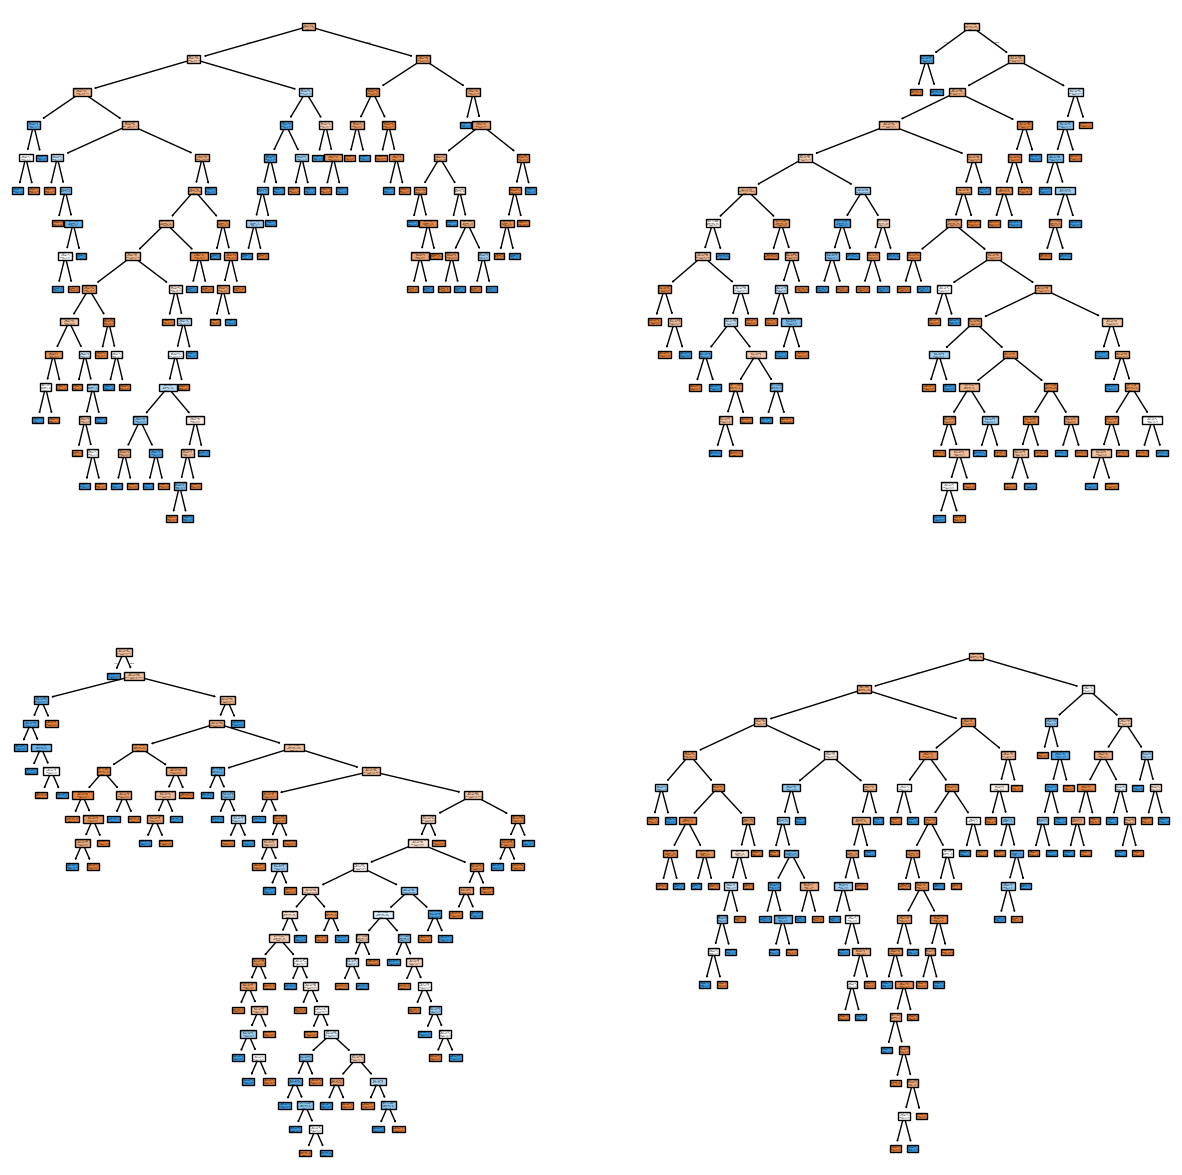

In [339]:
fig, axis = plt.subplots(2, 2, figsize = (15, 15))

# We show the first 4 trees out of the 100 generated (default)
tree.plot_tree(model.estimators_[0],
                ax = axis[0, 0], 
                 feature_names = list(train_dfs[0].columns),
                  class_names = ["0", "1"],
                    filled = True)

tree.plot_tree(model.estimators_[1],
                ax = axis[0, 1],
                  feature_names = list(train_dfs[0].columns),
                    class_names = ["0", "1"],
                      filled = True)

tree.plot_tree(model.estimators_[2],
                ax = axis[1, 0],
                  feature_names = list(train_dfs[0].columns),
                    class_names = ["0", "1"],
                      filled = True)

tree.plot_tree(model.estimators_[3],
                ax = axis[1, 1],
                  feature_names = list(train_dfs[0].columns),
                    class_names = ["0", "1"],
                      filled = True)

plt.show()